<a href="https://colab.research.google.com/github/Renad110/IT326/blob/main/Reports/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project Goal
The goal of this project is to perform classification and clustering tasks on the Bank Marketing dataset.

- Classification: Predict whether a client will subscribe to a term deposit.
- Clustering: Group clients with similar characteristics.

## Dataset Source
The dataset used in this project is the Bank Marketing Dataset, obtained from the UCI Machine Learning Repository.

- Source: UCI Machine Learning Repository – Bank Marketing Dataset  
- Link: [https://archive.ics.uci.edu/dataset/222/bank+marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing)  
- DOI: [https://doi.org/10.1016/j.dss.2014.03.001](https://doi.org/10.1016/j.dss.2014.03.001)

Dataset

Source: UCI Machine Learning Repository - Bank Marketing Dataset
File Used: bank-additional-full.csv
Rows: 41,188
Columns (features): 20
Class Label: y (yes/no) — whether the client subscribed to a bank term deposit.

In [91]:
import pandas as pd

data = pd.read_csv('https://raw.githubusercontent.com/Renad110/IT326/refs/heads/main/Dataset/Raw_dataset/bank-additional-full.csv', sep=';')

print("Number of instances (rows):", data.shape[0])
print("Number of attributes (columns):", data.shape[1])
print("\nClass Attribute (y) value counts:\n", data['y'].value_counts())
print("\nSample of the dataset:\n", data.head())

Number of instances (rows): 41188
Number of attributes (columns): 21

Class Attribute (y) value counts:
 y
no     36548
yes     4640
Name: count, dtype: int64

Sample of the dataset:
    age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1 

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
df = pd.read_csv('https://raw.githubusercontent.com/Renad110/IT326/refs/heads/main/Dataset/Raw_dataset/bank-additional-full.csv', sep=';')
raw_df = df.copy()


🔹 Statistical & Data Overview Analysis:
In this section, we explore the dataset by showing its structure, statistical summary, missing values, and outliers. This helps us understand data quality and what preprocessing might be needed later.

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

The dataset contains 41188 rows and 21 columns.  
Most of the attributes are either categorical or numeric,  
which means both types of analysis will be needed.

In [94]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


The table above provides a five-number summary and basic statistics for the numerical columns.
For example, we can see that the average of most numerical attributes, such as `age` and `duration`,
shows moderate variation between the minimum and maximum values, which helps identify data spread and potential outliers.


In [95]:
missing_values = df.isna().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


Missing Values Analysis:
We checked for missing values in each column. The output shows that all columns have zero missing values,
which means the dataset is complete and no imputation is required at this stage.


In [96]:
from scipy.stats import zscore
# sample dataset
data = df['age']

z_scores = zscore(data)
threshold = 2

outliers = data[abs(z_scores) > threshold]
print("Outliers:", outliers)


Outliers: 8645     61
15798    19
24110    18
27713    70
27715    61
         ..
41174    62
41178    62
41179    64
41183    73
41187    74
Name: age, Length: 985, dtype: int64


Outliers Detection: We used the Z-Score method on the age column to detect unusual values.
This method can also be applied to other numeric columns to find outliers.
The detected extreme values will be handled later during preprocessing.

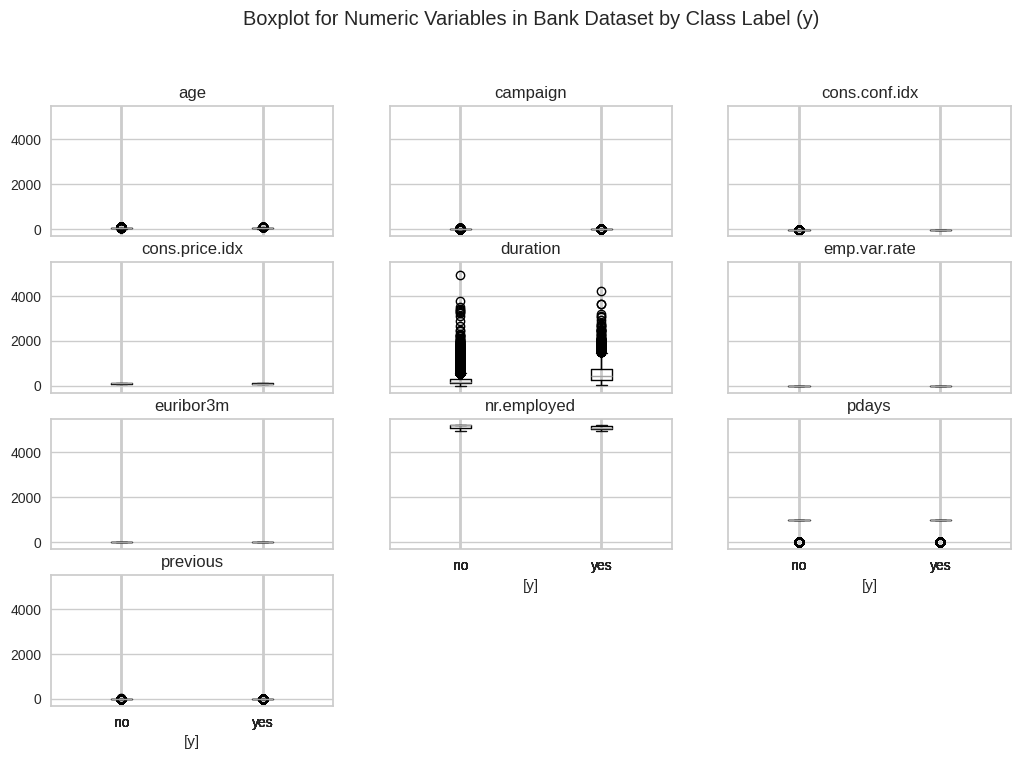

In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('https://raw.githubusercontent.com/Renad110/IT326/refs/heads/main/Dataset/Raw_dataset/bank-additional-full.csv', sep=';')
df.boxplot(by='y', figsize=(12, 8))
plt.suptitle('Boxplot for Numeric Variables in Bank Dataset by Class Label (y)', y=1.02)
plt.show()

The boxplot shows the distribution of numeric variables in the dataset, grouped by the target variable (y).
It helps identify outliers and compare how values differ between the “yes” and “no” classes.
For example, the “duration” variable shows more spread and outliers, which indicates it may strongly influence the model during training.

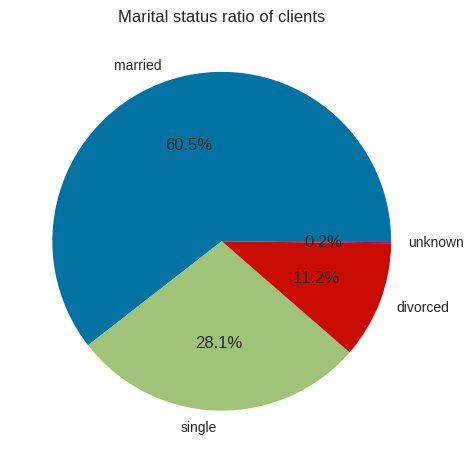

In [98]:
import matplotlib.pyplot as plt
df["marital"].value_counts().plot(kind="pie", autopct="%.1f%%", title="Marital status ratio of clients")
plt.ylabel("")
plt.show()

The pie chart shows that most clients are married, followed by single and divorced groups. It reveals a class imbalance leaning toward a specific social category. During preprocessing, this helps handle class bias or merge minor groups to maintain balanced data before encoding.

 This insight can later support feature selection by testing whether marital status significantly influences the subscription outcome.

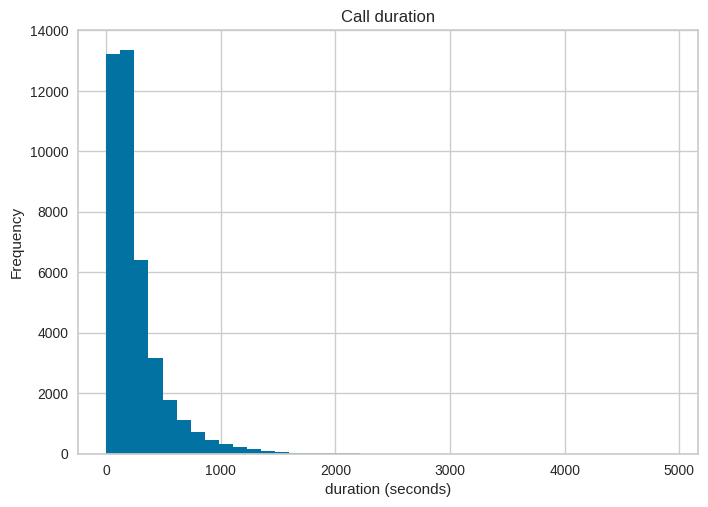

In [99]:
df["duration"].plot(kind="hist", bins=40, title="Call duration")
plt.xlabel("duration (seconds)")
plt.ylabel("Frequency")
plt.show()

The histogram shows the distribution of call durations, where most calls are short and few are long. It highlights large variation and potential outliers, which helps in preprocessing by applying normalization or removing extreme values to improve data quality.

It can later help determine whether call duration is a key predictive feature affecting client responses to campaigns.

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(


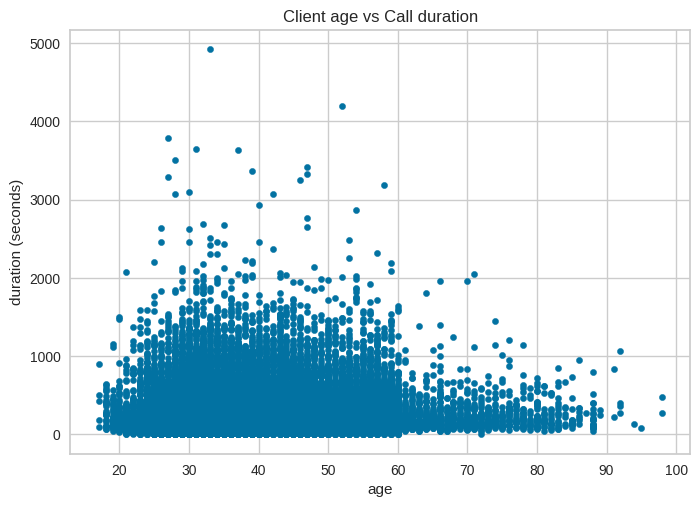

In [100]:
df.plot.scatter(x="age", y="duration", title="Client age vs Call duration")
plt.xlabel("age")
plt.ylabel("duration (seconds)")
plt.show()

The scatter plot shows the relationship between client age and call duration. It suggests that age has little effect on call length, which helps in preprocessing by analyzing feature correlation and deciding on normalization or feature selection.

This relationship can help evaluate whether age is a meaningful factor for understanding customer behavior or can be excluded.

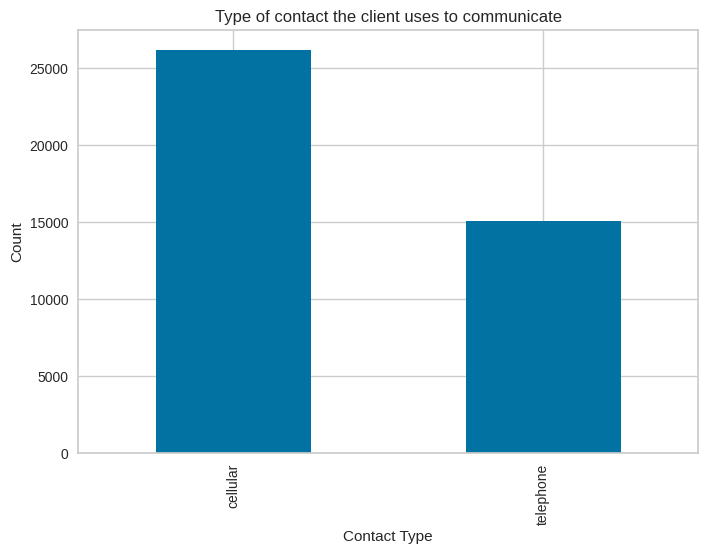

In [101]:
df['contact'].value_counts().plot(kind='bar', title='Type of contact the client uses to communicate')
plt.xlabel('Contact Type')
plt.ylabel('Count')
plt.show()

The bar chart shows that most clients were contacted via cellular phones rather than landlines, indicating the bank’s reliance on modern communication channels. This insight helps in preprocessing by applying categorical encoding and ensuring class balance.

this feature can be analyzed to see whether the contact method significantly affects client response or not.

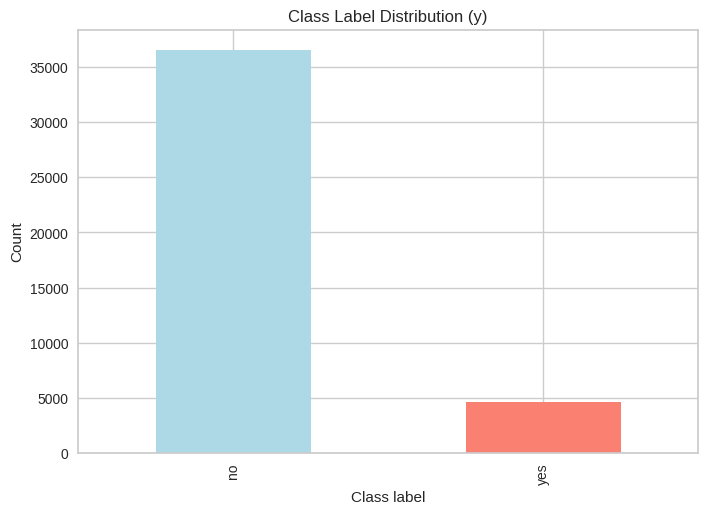

In [102]:
import matplotlib.pyplot as plt
df['y'].value_counts().plot(kind='bar', color=['lightblue', 'salmon'])
plt.title('Class Label Distribution (y)')
plt.xlabel('Class label')
plt.ylabel('Count')
plt.show()

Class Label Distribution: The bar plot shows the number of samples for each class in the target variable (y).
The dataset is imbalanced, with significantly more “no” responses than “yes.”
This imbalance should be considered during preprocessing or model training to ensure fair prediction performance.



---


**Data Preprocessing**
-

In [103]:

Q1 = df['duration'].quantile(0.25)
Q3 = df['duration'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

initial_len = len(df)
df = df[(df['duration'] <= upper_bound)].copy()

df['log_duration'] = np.log1p(df['duration'])

print(f"Cleaned 'duration' column. Initial rows: {initial_len}, Remaining rows: {len(df)}")



bins = [17, 30, 45, 60, 100]
labels = ['Youth (18-29)', 'Adult (30-44)', 'Middle Age (45-59)', 'Senior (60+)']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

print("Successfully created 'age_group' column through Discretization.")


scaler = MinMaxScaler()
numeric_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed', 'log_duration']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Numeric columns normalized successfully.")

print("- Before Preprocessing:")
display(raw_df.head())

print("- After Preprocessing:")
display(df.head())


Cleaned 'duration' column. Initial rows: 41188, Remaining rows: 38225
Successfully created 'age_group' column through Discretization.
Numeric columns normalized successfully.
- Before Preprocessing:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


- After Preprocessing:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,log_duration,age_group
0,0.481481,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.860740,Middle Age (45-59)
1,0.493827,services,married,high.school,unknown,no,no,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.774531,Middle Age (45-59)
2,0.246914,services,married,high.school,no,yes,no,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.838575,Adult (30-44)
3,0.283951,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.776578,Adult (30-44)
4,0.481481,services,married,high.school,no,no,yes,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.885744,Middle Age (45-59)


**Data Preprocessing Justification**

In this phase, several preprocessing techniques were applied to improve the dataset’s quality and prepare it for the data mining phase. The applied techniques include Noise Removal, Variable Transformation, Discretization, and Normalization.

**Noise Removal (Outlier Handling)**

* **Why:** Outliers in the duration column can negatively affect the analysis and model performance since they distort the scale of the data and bias statistical measures.

* **How:** The Interquartile Range (IQR) method was used to identify and remove extreme values above the upper bound (Q3 + 1.5*IQR).

* **On which attribute:** duration

* **Improvement:** Removing outliers reduced data variability and made the distribution more consistent, which helps classification and clustering algorithms perform more accurately.


**Variable Transformation (Log Transformation)**

* **Why:** The duration attribute had a highly skewed distribution. Log transformation was used to reduce skewness and make the data more normally distributed.

* **How:** A new column log_duration was created using the transformation log1p(duration).

* **On which attribute:** duration

* **Improvement:** The transformation reduced the impact of large values, allowing algorithms like Decision Trees and K-Means to treat all samples more equally.

**Discretization (Binning)**

* **Why:** Continuous numerical data in the age attribute was converted into categorical age groups to simplify interpretation and improve model interpretability.

* **How:** The age column was divided into four bins.

* **On which attribute:** age

* **Improvement:** This technique made the data more understandable and suitable for classification algorithms that can benefit from categorical features.

**Normalization (Min–Max Scaling)**

* **Why:** The numeric attributes had different scales (e.g., age, duration, etc.), which can bias distance-based algorithms such as K-Means.

* **How:** The Min–Max Scaler from sklearn was applied to rescale all numeric features into the range [0, 1].

* **On which attributes:** Numeric attributes.

* **Improvement:** Scaling unified the range of values across features, ensuring that all attributes contribute equally to the learning process.

**Summary of Results**

After preprocessing, the dataset became cleaner, more balanced, and more suitable for machine learning tasks. Outliers were removed, distributions were smoothed, and numeric attributes were scaled consistently.

In [104]:
# Save the preprocessed dataset
df.to_csv('Preprocessed_dataset.csv', index=False)


---

**Classification**
-

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

In [106]:
data = pd.read_csv('https://raw.githubusercontent.com/Renad110/IT326/refs/heads/main/Dataset/Preprocessed_dataset.csv')
df_encoded = data.copy()
le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

In [107]:
test_sizes = [0.2, 0.3, 0.4]
criteria = ["gini", "entropy"]

results_list = []

print("=" * 75)
print(f"{'Test Split %':<15} | {'Criterion':<10} | {'Accuracy':<10} | {'F1-Score (Yes)':<15}")
print("=" * 75)

Test Split %    | Criterion  | Accuracy   | F1-Score (Yes) 


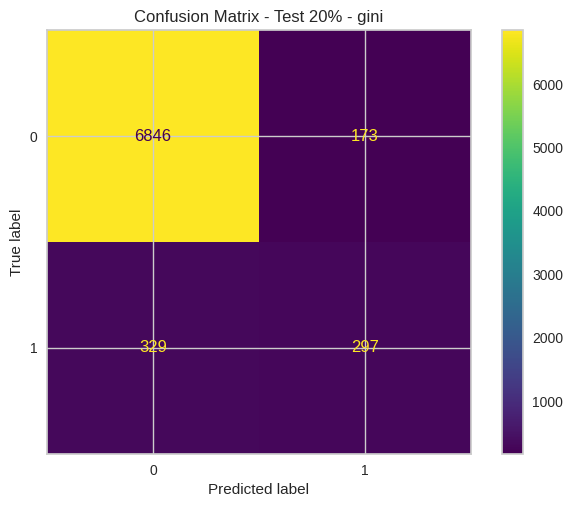

20              | gini       | 0.9343


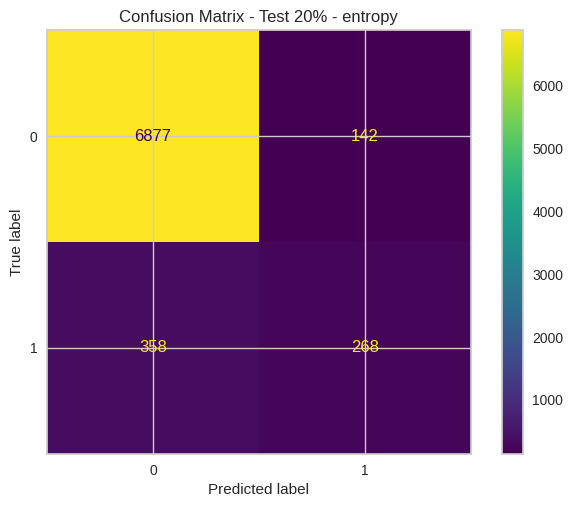

20              | entropy    | 0.9346


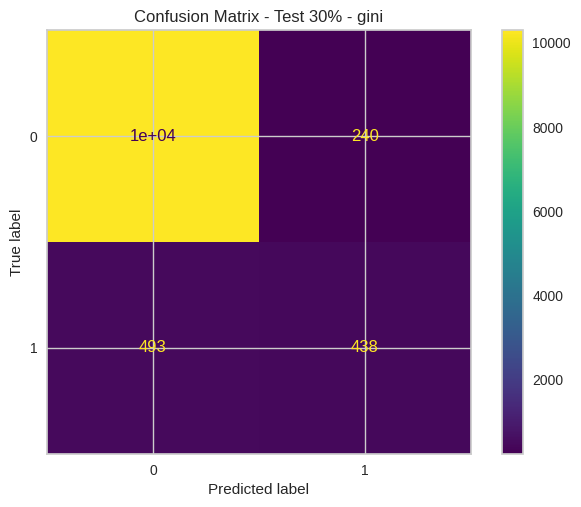

30              | gini       | 0.9361


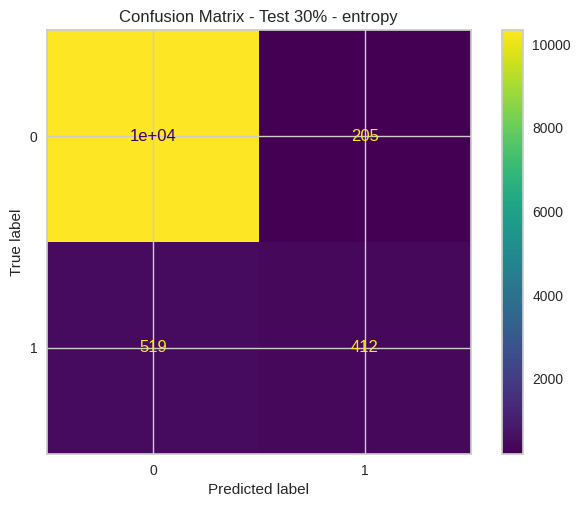

30              | entropy    | 0.9369


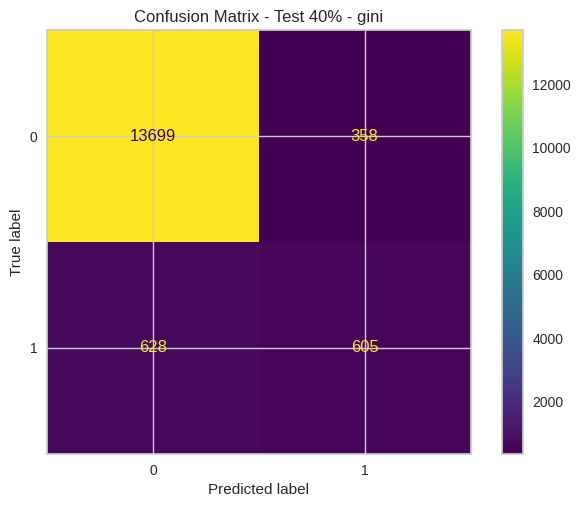

40              | gini       | 0.9355


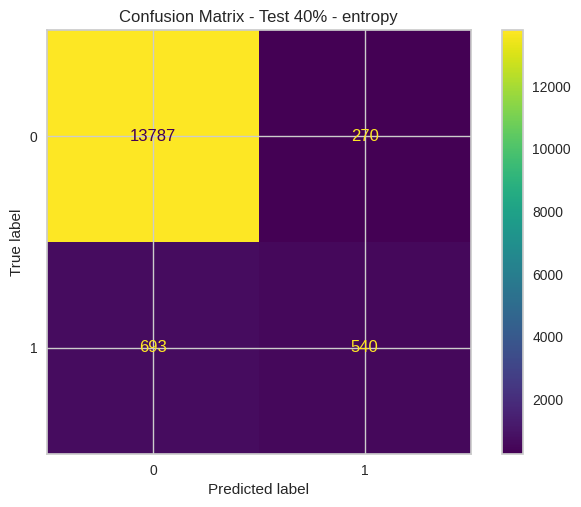

40              | entropy    | 0.9370


In [108]:
for t_size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=t_size, random_state=42)

    for crit in criteria:
        clf = DecisionTreeClassifier(criterion=crit, max_depth=4, random_state=42)

        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)

        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()
        plt.title(f"Confusion Matrix - Test {int(t_size*100)}% - {crit}")
        plt.show()

        results_list.append({
            "Test Size": f"{t_size*100}%",
            "Criterion": crit,
            "Accuracy": acc,
            "Model": clf
        })

        print(f"{t_size*100:<15.0f} | {crit:<10} | {acc:.4f}")

print("=" * 75)

Generating 6 Decision Tree visualizations as separate outputs...


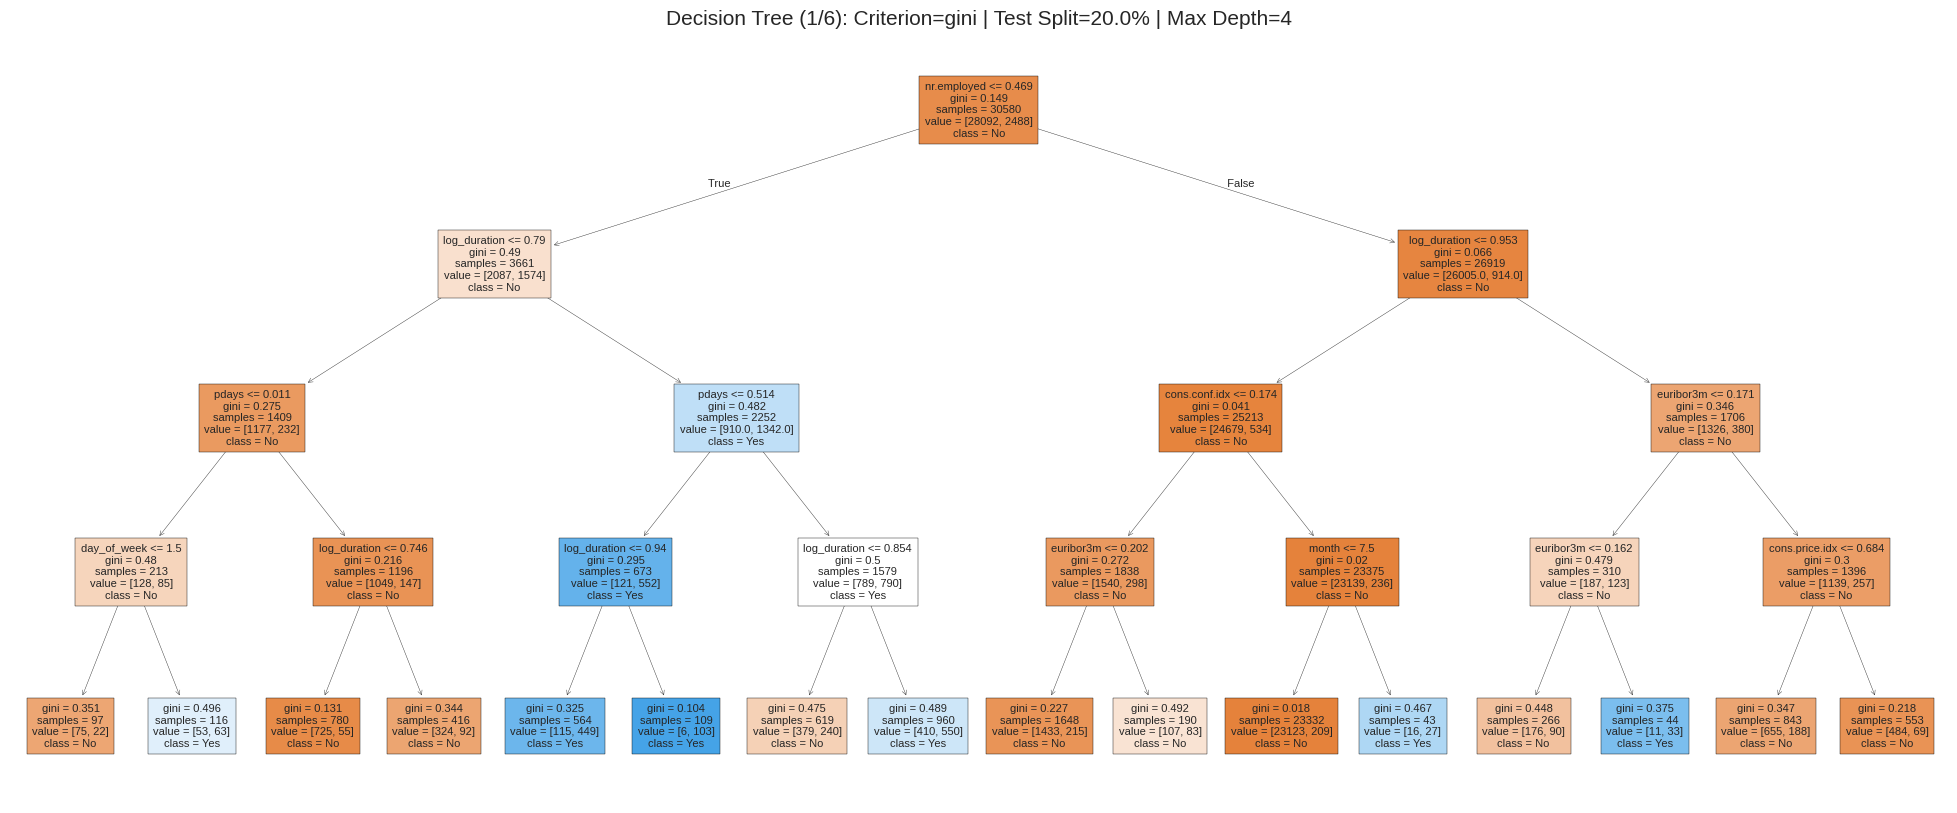

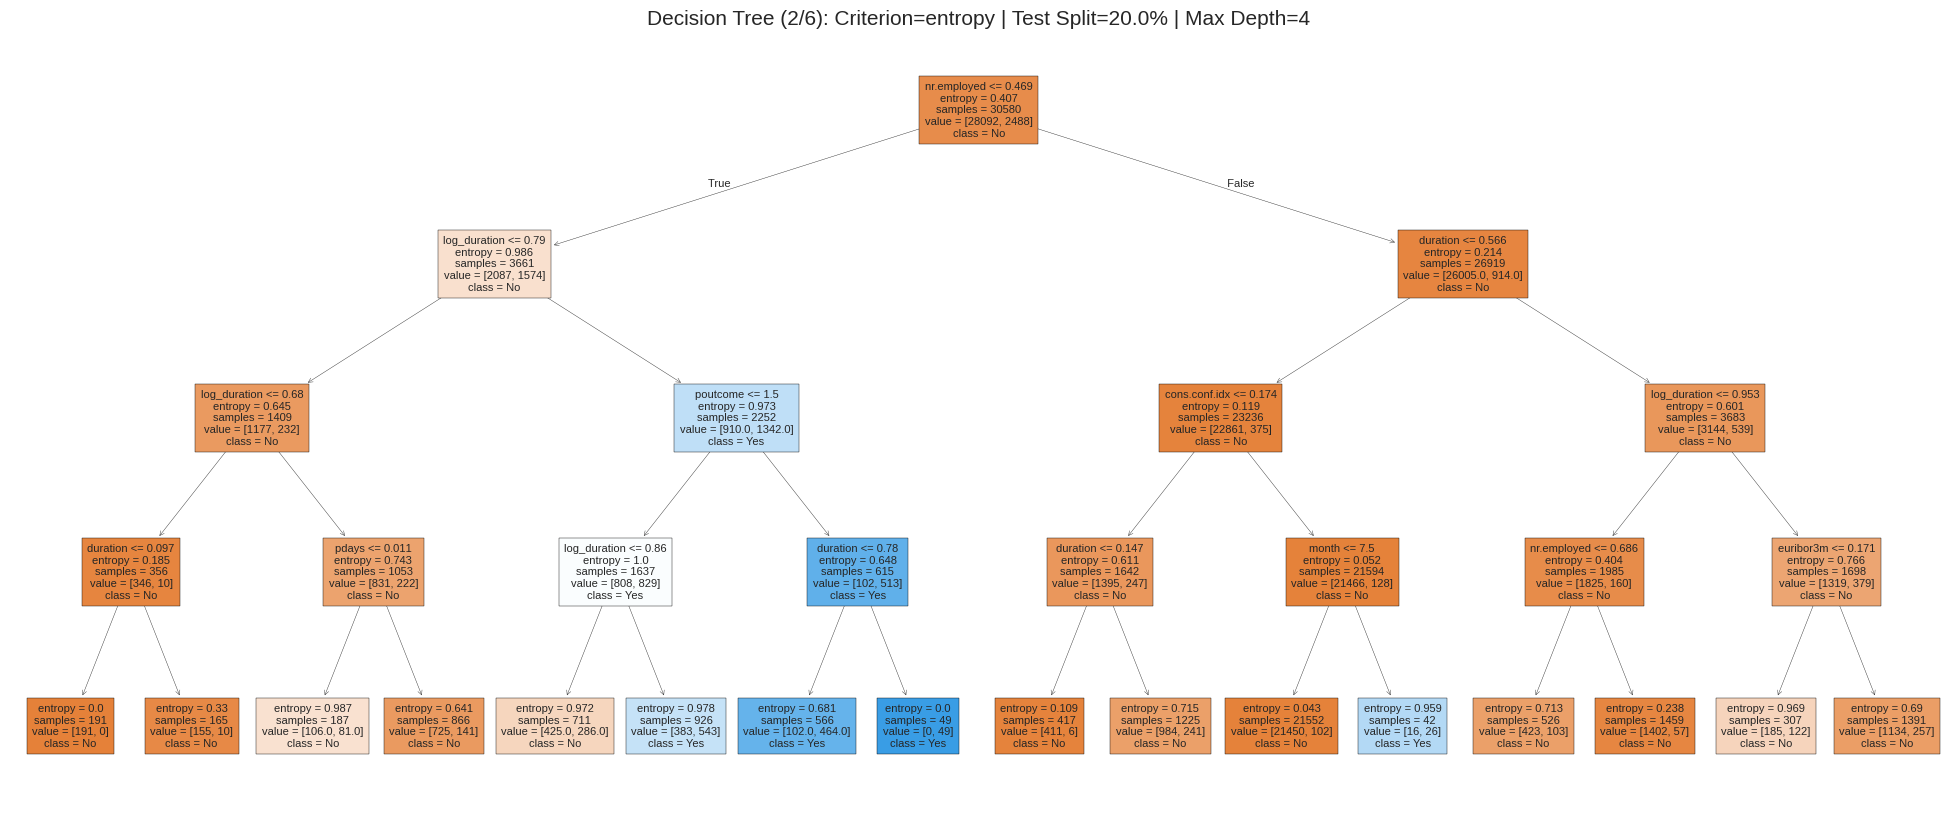

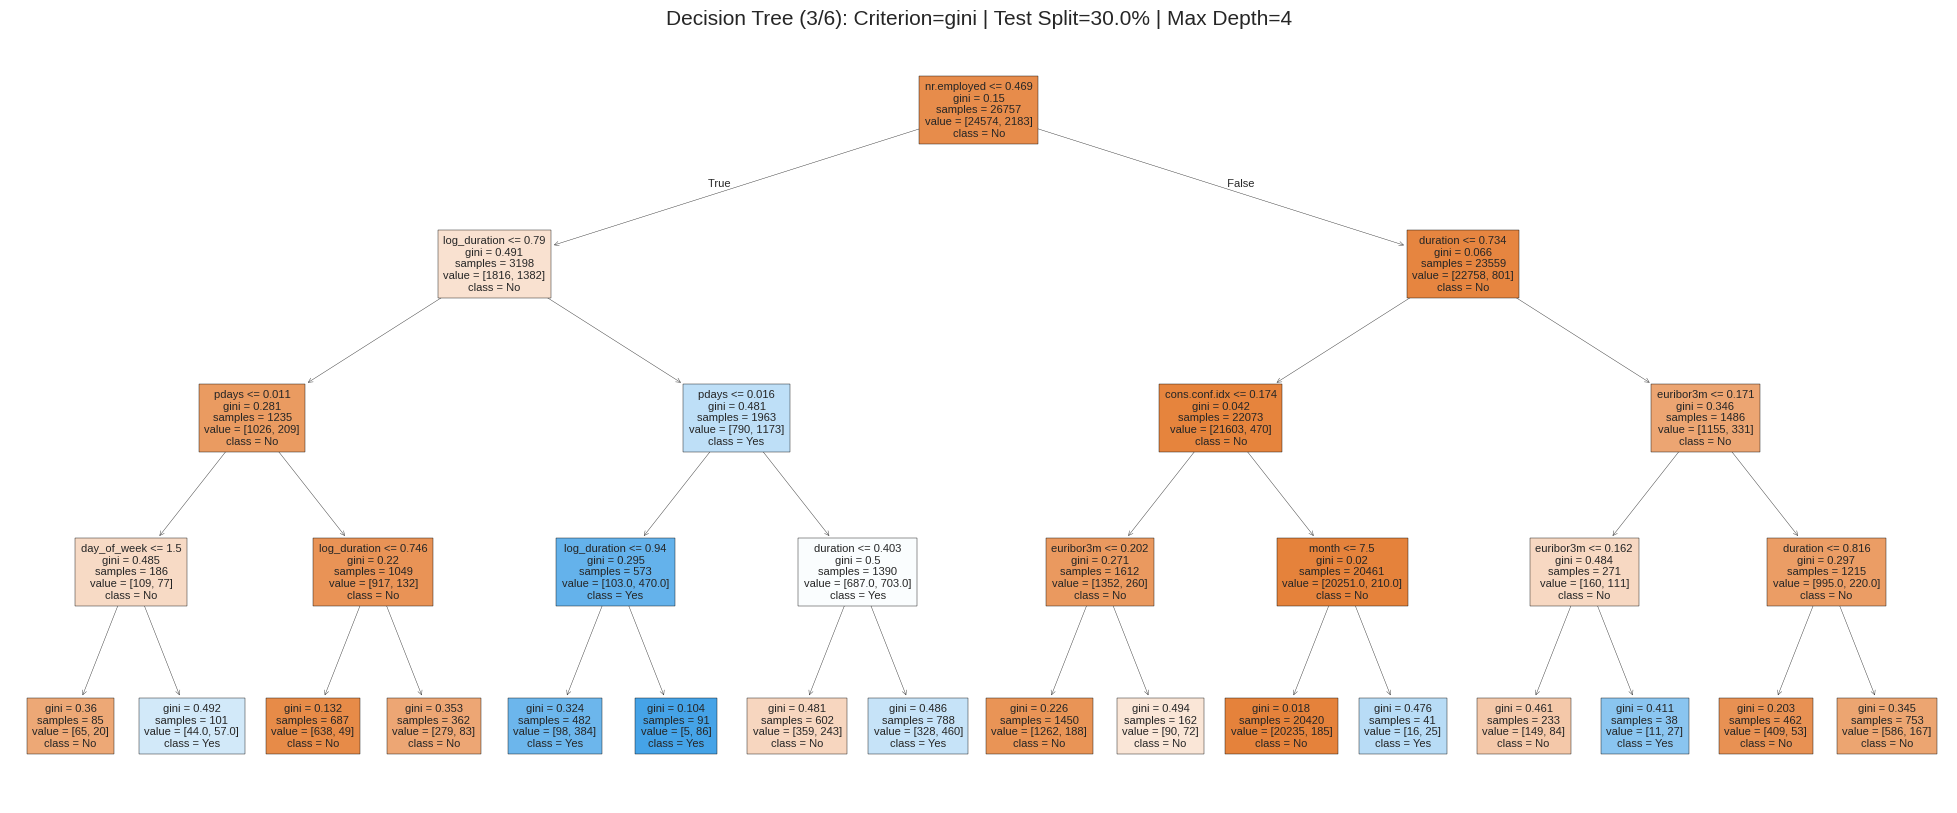

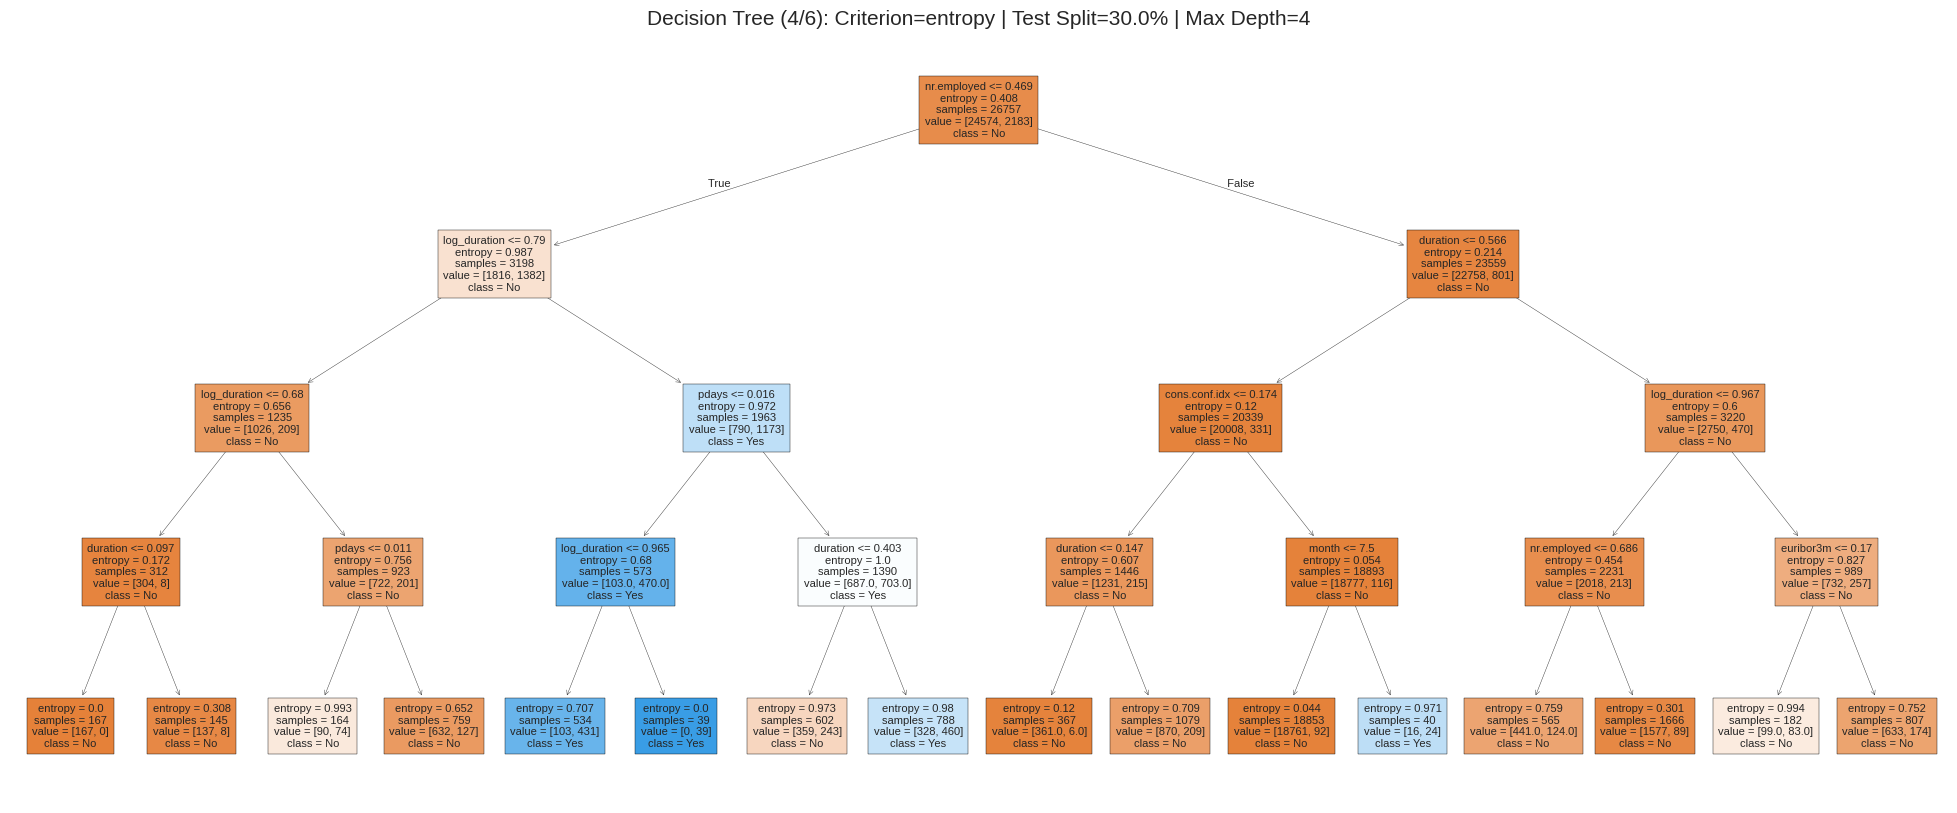

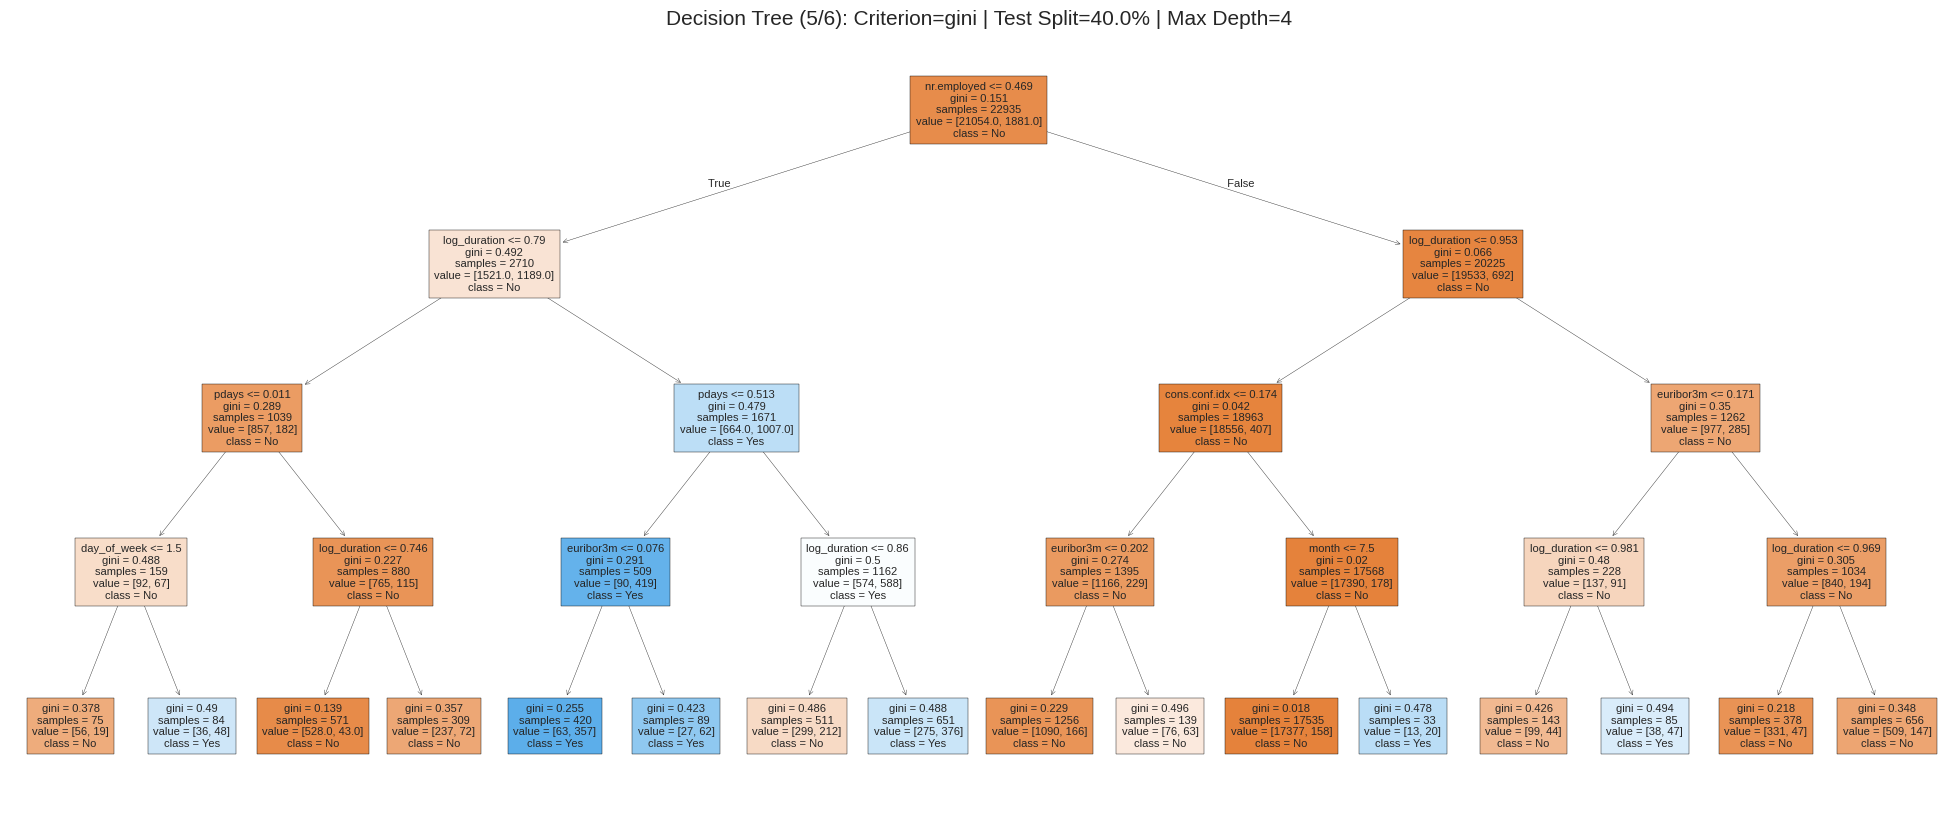

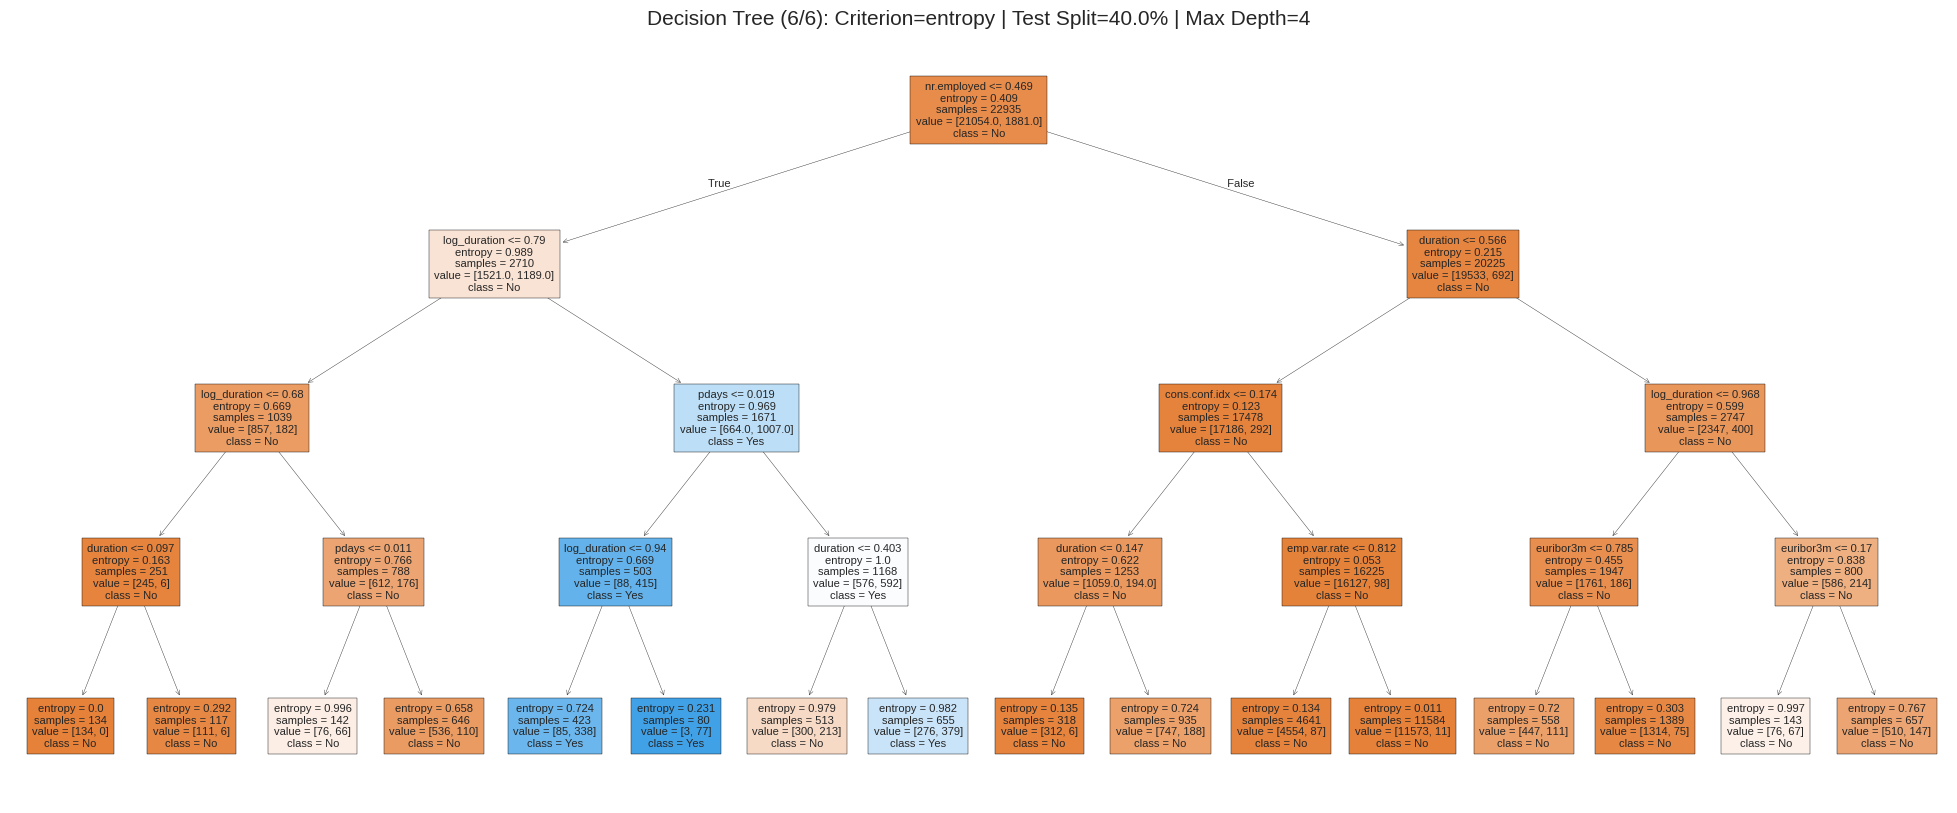

In [109]:
feature_names = X.columns.tolist()
class_names = ['No', 'Yes']

print("Generating 6 Decision Tree visualizations as separate outputs...")

for i, result in enumerate(results_list):
    model = result['Model']
    test_size = result['Test Size']
    criterion = result['Criterion']

    fig, ax = plt.subplots(figsize=(25, 10))

    plot_tree(model,
              feature_names=feature_names,
              class_names=class_names,
              filled=True,
              fontsize=8,
              ax=ax)

    title = f"Decision Tree ({i+1}/6): Criterion={criterion} | Test Split={test_size} | Max Depth={model.max_depth}"
    ax.set_title(title, fontsize=15)


    plt.show()

    plt.close(fig)

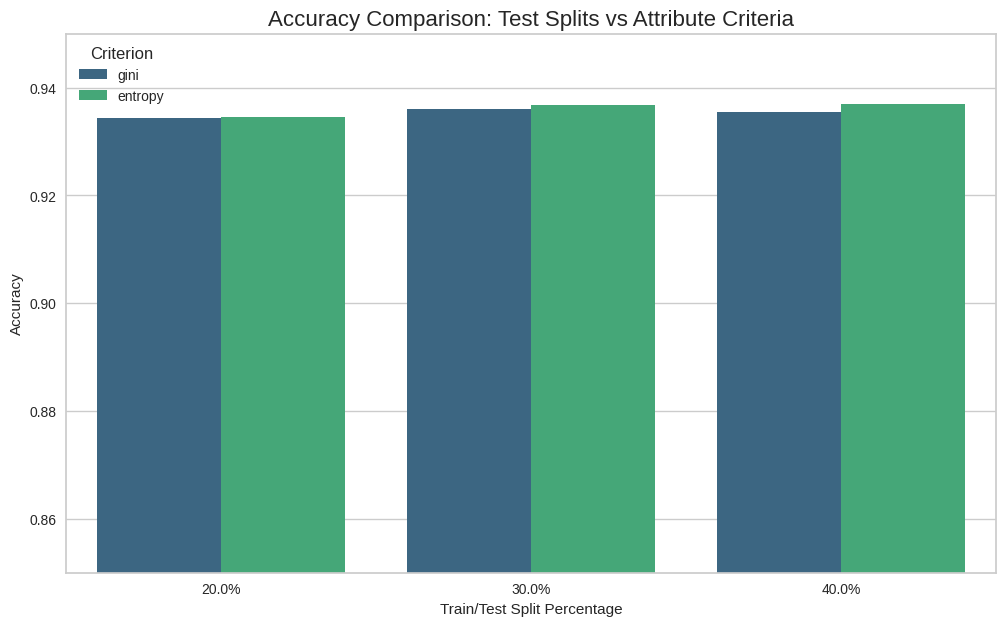

In [110]:
results_df = pd.DataFrame(results_list)

plt.figure(figsize=(12, 7))
sns.barplot(x="Test Size", y="Accuracy", hue="Criterion", data=results_df, palette="viridis")
plt.title("Accuracy Comparison: Test Splits vs Attribute Criteria", fontsize=16)
plt.ylim(0.85, 0.95)
plt.ylabel("Accuracy")
plt.xlabel("Train/Test Split Percentage")
plt.show()


---

**Clustering**
-

In [111]:
import pandas as pd
url = "https://raw.githubusercontent.com/Renad110/IT326/refs/heads/main/Dataset/Preprocessed_dataset.csv"
df = pd.read_csv(url)
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,log_duration,age_group
0,0.481481,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.860740,Middle Age (45-59)
1,0.493827,services,married,high.school,unknown,no,no,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.774531,Middle Age (45-59)
2,0.246914,services,married,high.school,no,yes,no,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.838575,Adult (30-44)
3,0.283951,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.776578,Adult (30-44)
4,0.481481,services,married,high.school,no,no,yes,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.885744,Middle Age (45-59)


In [123]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

features = df.copy()

categorical_features = features.select_dtypes(include=['object']).columns
numerical_features = features.select_dtypes(exclude=['object']).columns

df_categorical_encoded = pd.get_dummies(features[categorical_features], drop_first=True)

features_processed = pd.concat([features[numerical_features], df_categorical_encoded], axis=1)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_processed)

df_scaled = pd.DataFrame(scaled_features, columns=features_processed.columns)
print("\nScaled DataFrame:")
print(df_scaled.head())


Scaled DataFrame:
        age  duration  campaign    pdays  previous  emp.var.rate  \
0  1.529988  0.409496  -0.56064  0.19302 -0.350216      0.647802   
1  1.625909 -0.384744  -0.56064  0.19302 -0.350216      0.647802   
2 -0.292514  0.161296  -0.56064  0.19302 -0.350216      0.647802   
3 -0.004750 -0.370561  -0.56064  0.19302 -0.350216      0.647802   
4  1.529988  0.735701  -0.56064  0.19302 -0.350216      0.647802   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed  ...  \
0        0.723987       0.880956   0.711926      0.33116  ...   
1        0.723987       0.880956   0.711926      0.33116  ...   
2        0.723987       0.880956   0.711926      0.33116  ...   
3        0.723987       0.880956   0.711926      0.33116  ...   
4        0.723987       0.880956   0.711926      0.33116  ...   

   day_of_week_mon  day_of_week_thu  day_of_week_tue  day_of_week_wed  \
0          1.94497        -0.512113        -0.495336         -0.49423   
1          1.94497        -0.512113

/tmp/ipython-input-2966858541.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


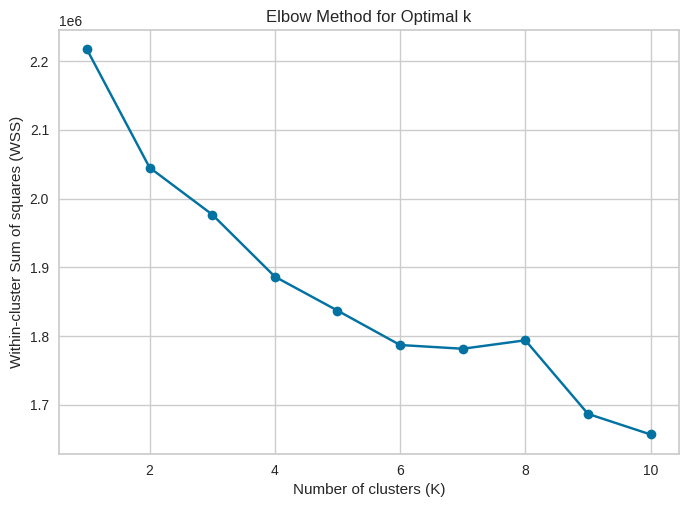

In [124]:
!pip install kneed
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from kneed import KneeLocator

wcss_values = []
K_values = range(1, 11)

for k in K_values:
    kmeans = make_pipeline(StandardScaler(), KMeans(n_clusters=k))
    kmeans.fit(df_scaled)
    wcss_values.append(kmeans.named_steps['kmeans'].inertia_)

plt.plot(K_values, wcss_values, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Within-cluster Sum of squares (WSS)")
plt.title("Elbow Method for Optimal k")
plt.legend()
plt.show()

In [125]:
import numpy as np
from sklearn.cluster import KMeans
np.random.seed(42)

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_result = kmeans.fit(df_scaled)

print("Cluster Centers:")
print(kmeans.cluster_centers_)

print("\nCluster Labels:")
print(kmeans_result.labels_)

Cluster Centers:
[[ 1.77890079e-02 -4.44570688e-02  9.29265283e-02  1.93019609e-01
  -3.46340484e-01  6.78232909e-01  4.91595512e-01  2.40144596e-01
   6.99731983e-01  6.47699581e-01 -3.47360969e-02  2.79822033e-02
   1.20827823e-02  2.63060319e-02 -5.43672421e-05 -6.39525163e-02
   5.26769084e-03  5.43448087e-03 -9.94318822e-02  3.39864893e-02
  -7.69413976e-03  1.33057479e-02  6.58082621e-02 -7.97978400e-02
  -6.04531696e-03  1.32599995e-02  7.59495510e-03 -1.62645865e-02
  -9.43198350e-04  1.37957970e-02 -2.12456947e-02  9.39274111e-04
   1.36882272e-01  4.66227941e-03  5.87429452e-03 -4.28167436e-02
   5.87429452e-03 -1.89635318e-03  2.94673069e-01  1.17280720e-01
  -6.50362850e-02  1.91357026e-01  9.83351259e-02 -1.17893323e-01
  -9.82203762e-02  2.76347007e-02 -1.14887203e-01 -1.16862547e-01
  -1.95741778e-02 -6.94754493e-03  1.46255195e-02  2.08466266e-02
   3.93133695e-01 -1.83713663e-01 -2.38693530e-01  8.40563458e-02
  -1.33962161e-01 -8.19437228e-02]
 [-3.38031641e-02  8.447

In [126]:
import numpy as np
from sklearn.cluster import KMeans
np.random.seed(42)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_result = kmeans.fit(df_scaled)

print("Cluster Centers:")
print(kmeans.cluster_centers_)

print("\nCluster Labels:")
print(kmeans_result.labels_)

Cluster Centers:
[[ 1.27765234e-02 -9.18995302e-02  8.00103122e-02  1.93019609e-01
  -2.57948133e-01  6.15775775e-01  2.38383671e-02  4.42419220e-02
   6.59004009e-01  7.41204651e-01 -7.24957290e-02 -1.03383679e-01
   9.66198910e-03  3.35892213e-02  2.03591966e-02 -6.08758350e-02
   1.29107577e-02 -4.28395153e-02 -1.06714815e-01  1.22420449e-01
  -2.90968239e-03 -1.74101990e-02  8.00326916e-03 -2.30253455e-02
  -1.04318130e-02 -5.06529171e-02 -7.00975565e-02 -4.39802049e-02
   1.39601407e-02  5.64919053e-02  1.19865440e-01 -3.21685230e-02
   1.68700600e-02  1.49858595e-02 -2.99375255e-02  5.28393374e-02
  -2.99375255e-02  1.42271193e-02 -5.66958754e-01  5.29272936e-01
  -6.50362850e-02  6.72004242e-01 -3.86857385e-01 -1.17893323e-01
  -7.10286303e-01  4.45951974e-01 -1.31031870e-01 -1.16862547e-01
  -1.59860457e-02  4.86390048e-02  2.58383352e-02  2.00290921e-02
   2.66073918e-01 -1.83713663e-01 -2.27022530e-01  1.09819417e-01
  -1.42423517e-01 -8.69071862e-02]
 [-3.89031974e-02  9.827

In [127]:
import numpy as np
from sklearn.cluster import KMeans
np.random.seed(42)

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_result = kmeans.fit(df_scaled)

print("Cluster Centers:")
print(kmeans.cluster_centers_)

print("\nCluster Labels:")
print(kmeans_result.labels_)

Cluster Centers:
[[ 1.25274203e-02 -9.18988965e-02  8.03906645e-02  1.93019609e-01
  -2.57483050e-01  6.15825240e-01  2.40873744e-02  4.37607776e-02
   6.59002021e-01  7.41227877e-01 -7.26108505e-02 -1.02016602e-01
   9.43621082e-03  3.33678325e-02  2.05747578e-02 -6.10424609e-02
   1.22971570e-02 -4.24421198e-02 -1.06759570e-01  1.21784017e-01
  -3.08644849e-03 -1.74923620e-02  8.61448257e-03 -2.33878047e-02
  -1.04686182e-02 -5.05604881e-02 -6.84972508e-02 -4.38789056e-02
   1.39214027e-02  5.59974258e-02  1.19155807e-01 -3.23677610e-02
   1.81752932e-02  1.49590256e-02 -3.00809516e-02  5.23027625e-02
  -3.00809516e-02  1.45211126e-02 -5.65283226e-01  5.28396060e-01
  -6.50362850e-02  6.72978836e-01 -3.86857385e-01 -1.17893323e-01
  -7.10286303e-01  4.46014516e-01 -1.31573232e-01 -1.16862547e-01
  -1.62007270e-02  4.83546884e-02  2.63128202e-02  2.01586591e-02
   2.65405385e-01 -1.83713663e-01 -2.26587958e-01  1.09607396e-01
  -1.42458755e-01 -8.62349064e-02]
 [-6.61696242e-02  6.051

In [129]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_values = [2, 3, 4]

silhouette_scores = []
wcss = []

print("Silhouette Scores:")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    silhouette = silhouette_score(df_scaled, labels)
    silhouette_scores.append(silhouette)
    print(f"K = {k} , Silhouette = {silhouette}")

print("\nWCSS:")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
    print(f"K = {k} , WCSS = {kmeans.inertia_}")

Silhouette Scores:
K = 2 , Silhouette = 0.11964197425091945
K = 3 , Silhouette = 0.04107922888258475
K = 4 , Silhouette = 0.057289917271626724

WCSS:
K = 2 , WCSS = 2045064.587603816
K = 3 , WCSS = 1976699.0226044883
K = 4 , WCSS = 1886291.7630808812


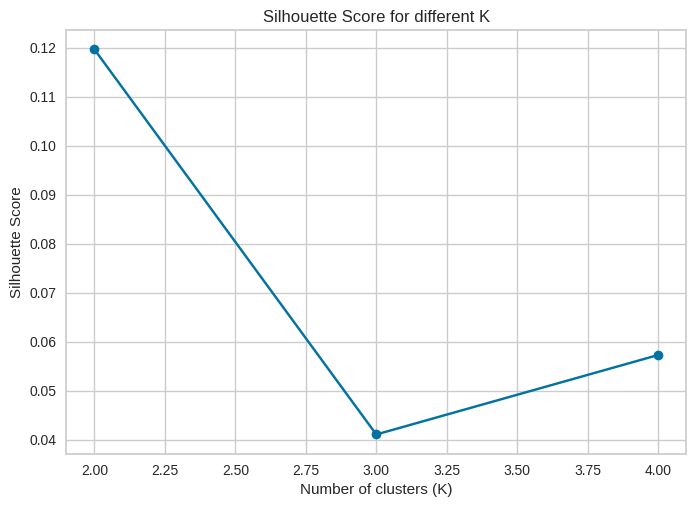

In [130]:
# Plot Silhouette for the 3 Ks
plt.plot(k_values, silhouette_scores, marker='o')
plt.title("Silhouette Score for different K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

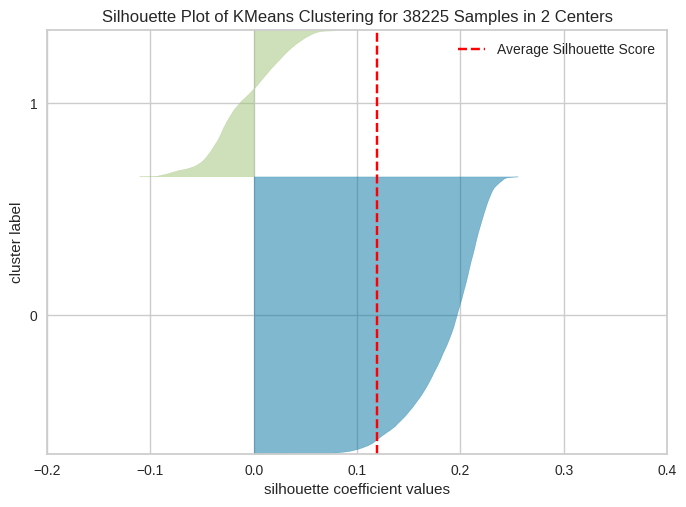

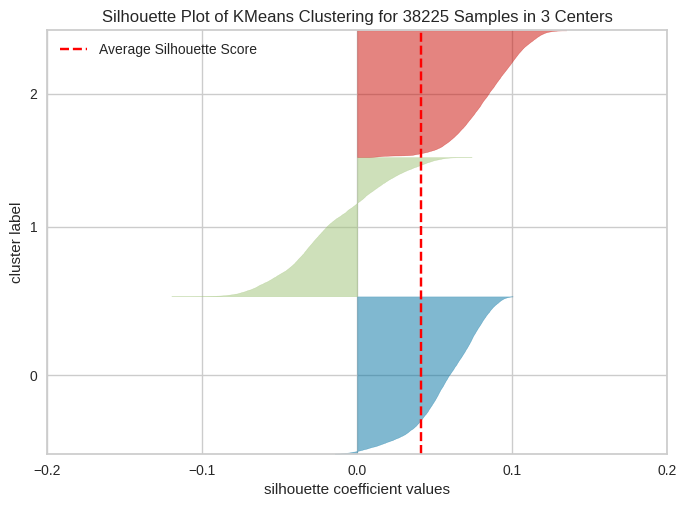

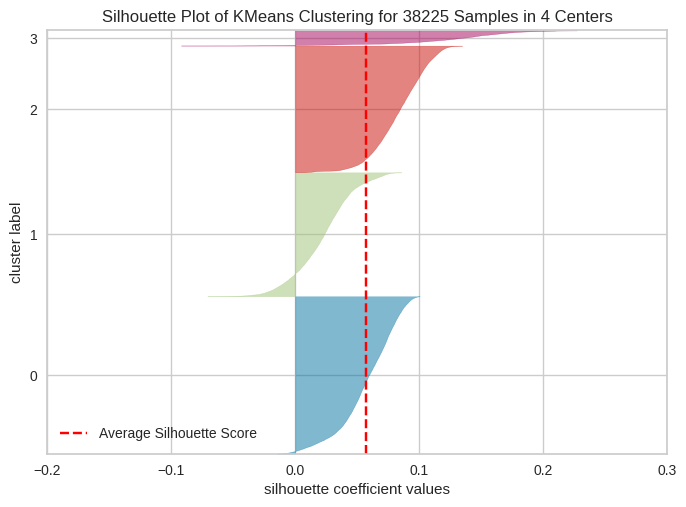

In [131]:
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k_values = [2, 3, 4]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    visualizer = SilhouetteVisualizer(kmeans, colors="yellowbrick")
    visualizer.fit(df_scaled)
    visualizer.show()

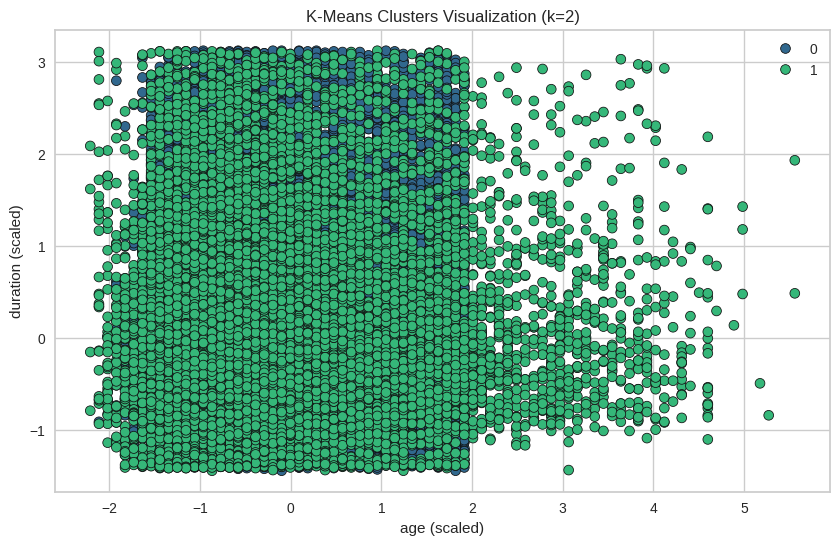

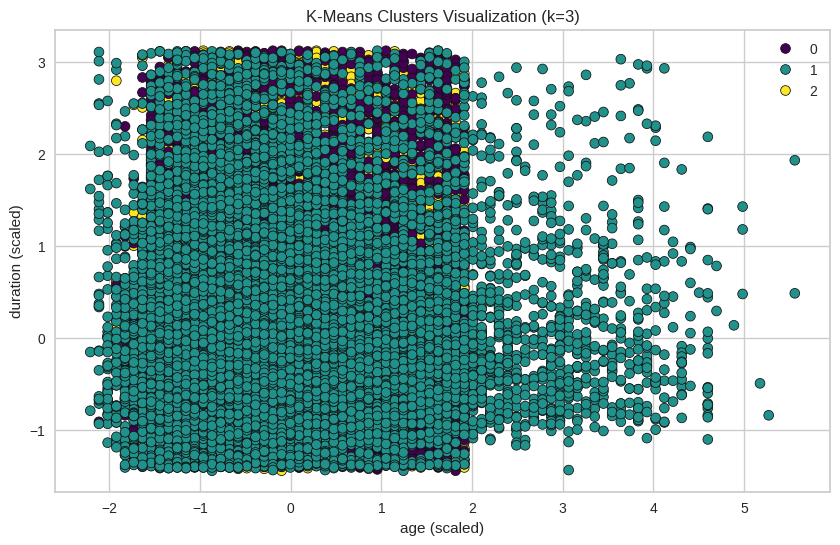

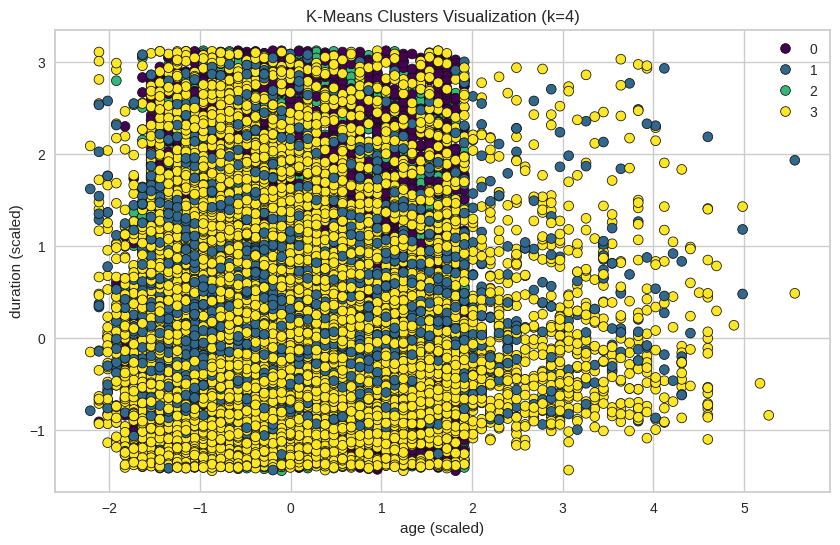

In [132]:
!pip install seaborn
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns

k_values = [2, 3, 4]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans_result = kmeans.fit(df_scaled)

    df_scaled["Cluster"] = kmeans_result.labels_

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        x="age",
        y="duration",
        hue="Cluster",
        data=df_scaled ,
        palette="viridis",
        edgecolor="k"
)

    plt.title(f"K-Means Clusters Visualization (k={k})")
    plt.xlabel("age (scaled)")
    plt.ylabel("duration (scaled)")
    plt.legend()
    plt.show()

# **[1] Problem**

The main problem is predicting whether a bank client will subscribe to a term deposit. Using customer information and details from previous marketing campaigns, we aim to identify the factors that influence this decision.Solving this problem is important because understanding client behavior helps the bank improve its marketing strategies, reduce unnecessary campaign efforts, and reach the right customers more effectively.

# **[2] Data Mining Task**

The problem is formalized using two data mining tasks:
-

**1- Classification task:**

 Uses the class label “y” to predict whether a client will subscribe to a term deposit, making it a supervised learning approach.


**2- Clustering task:**

Applied as an unsupervised technique to group clients based on similarities in their attributes. This provides insight into natural segments within the dataset and helps explain behavioral patterns beyond the class label.

# **[3] Data**

The dataset contains **41,188 rows** and **21 attributes** that describe bank clients and details related to previous marketing interactions. The attributes include both **categorical** (such as job, marital status, education, and contact type) and **numerical features** (such as age, duration, previous contacts, and employment-related indicators).


The class label (y), indicates whether the client subscribed to a term deposit. Its distribution is **highly imbalanced**, with **36,548 “no”** responses and **4,640 “yes”**, meaning the majority of clients did not subscribe.

# **[4] Data Preprocessing**

During preprocessing, several steps were applied to improve data quality and prepare the dataset for classification and clustering.

These steps are :



**1- Noise Removal (Outlier Handling)**

Why: The duration column had extreme outliers that could distort analysis and mislead models.

How: Outliers were detected and removed using the Interquartile Range (IQR) method (values above Q3 + 1.5×IQR).

Result: The distribution became more stable, reducing noise and improving model accuracy.



**2- Variable Transformation (Log Transformation)**

Why: The duration attribute was highly skewed, which affects algorithms that assume normal-like distributions.

How: A new column log_duration was created using log1p(duration).

Result: The transformation reduced skewness, made the distribution smoother, and prevented large values from dominating.


**3- Discretization (Binning)**

Why: The age column is continuous and had wide variation, making interpretation harder.

How: Age was divided into four age groups (bins).

Result: The attribute became easier to interpret and more suitable for classification models that benefit from categorical inputs.


**4- Normalization (Min–Max Scaling)**

Why: Numeric columns had different scales (e.g., age vs. duration vs. pdays). Without scaling, large-range attributes can dominate distance-based models.

How: Applied Min–Max Scaling to convert all numeric features into the range [0, 1].

Result: All numeric attributes now contribute equally during model training.

**Summary of Results**

After preprocessing, the dataset became cleaner, more balanced, and more suitable for machine learning tasks. Outliers were removed, distributions were smoothed, and numeric attributes were scaled consistently.

# **[5] Data Mining Techniques**

**1- Classification – Decision Trees**

* **Method:** Decision Tree Classifier


* **Packages:**
sklearn.tree.DecisionTreeClassifier,
train_test_split, LabelEncoder,
accuracy_score, confusion_matrix, ConfusionMatrixDisplay


* **Why :**

    To predict whether a client subscribes to a term deposit and understand which features drive the decision.

* **How :**

    * Encoded categorical variables using LabelEncoder.

    * Split data into train/test using train_test_split.

    * Trained Decision Trees with two criteria: Gini and Entropy.

    * Evaluated performance using Accuracy and Confusion Matrix.

    * Visualized results using matplotlib.

**2- Clustering – K-means**

* **Method:** K-Means

* **Packages:**
sklearn.cluster.KMeans,
StandardScaler, silhouette_score,
matplotlib, seaborn



* **Why :**

    To discover natural customer groups in the dataset and analyze hidden patterns.

* **How :**

    * Applied One-Hot Encoding and Standardization.

    * Ran K-Means with K = 2, 3, 4.

    * Evaluated clusters using Silhouette Score and Elbow (WCSS).

    * Visualized clusters using scatter plots.

# **[6] Evaluation and Comparison**

## Classification – Evaluation and Comparison

In this section, a **Decision Tree classifier** was applied using two different attribute selection measures:

- **Gini Index**
- **Information Gain (Entropy)**

Each measure was evaluated under three different data partitioning ratios:

- **80% training / 20% testing**
- **70% training / 30% testing**
- **60% training / 40% testing**

These experiments allow us to compare the performance of both criteria across different data splits.

---

## **1. Summary Tables**

The following two tables summarize the accuracy results for each attribute selection measure, across all partitioning ratios.

### Gini Index – Accuracy Table

|                        | 80% training 20% testing | 70% training 30% testing | 60% training 40% testing |
|------------------------|---------------------------|---------------------------|---------------------------|
| **Accuracy**           | **0.9343** | **0.9361**| **0.9355**|



### Information Gain – Accuracy Table

|                        | 80% training 20% testing | 70% training 30% testing | 60% training 40% testing |
|------------------------|---------------------------|---------------------------|---------------------------|
| **Accuracy**           | **0.9346** | **0.9369**| **0.9370**|

---

## **2. Confusion Matrices**

A confusion matrix was generated for **each combination** of partitioning ratio and attribute selection measure (Gini and Entropy).

These matrices illustrate how well the classifier distinguishes between the two classes ("yes" and "no") and highlight any misclassification patterns.


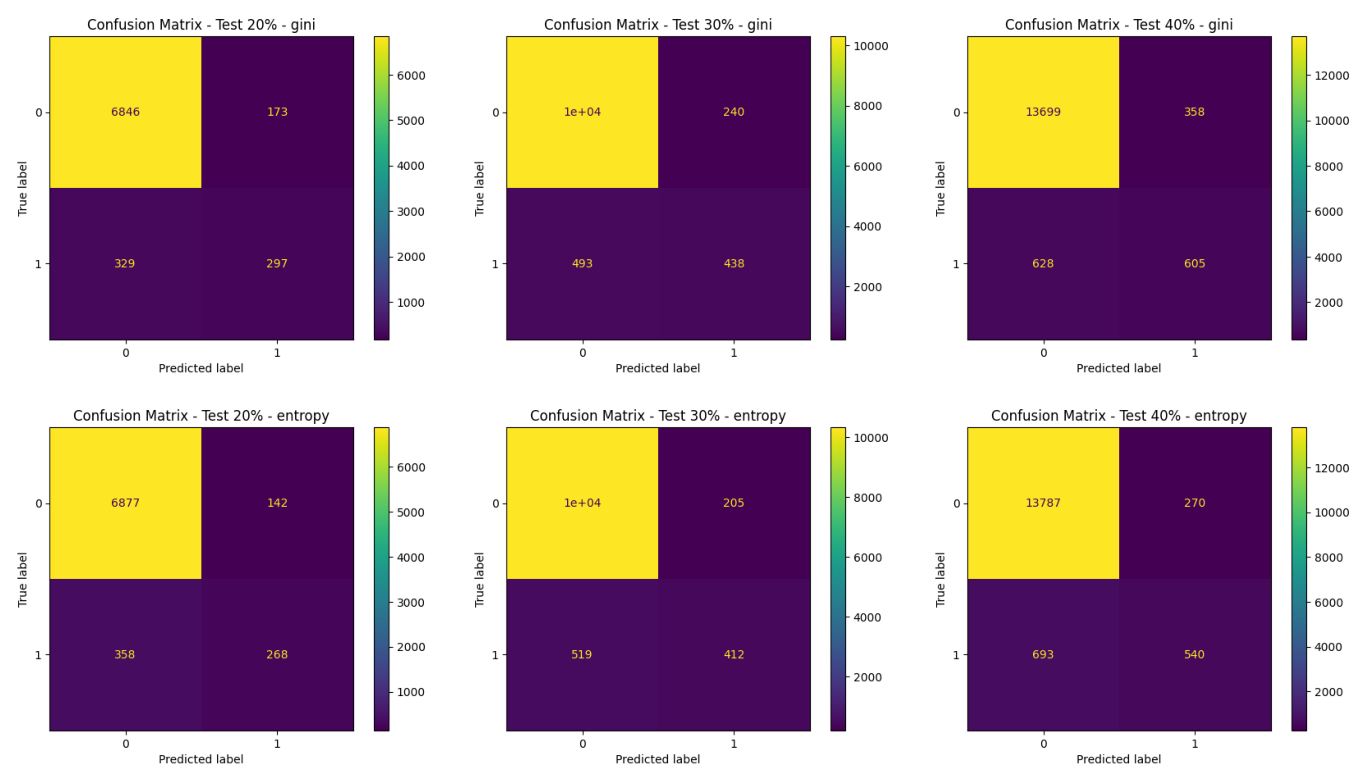

In [133]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import urllib.request
from PIL import Image
import numpy as np

paths = [
    "https://raw.githubusercontent.com/Renad110/IT326/refs/heads/main/images/gini-20.png",
    "https://raw.githubusercontent.com/Renad110/IT326/refs/heads/main/images/gini-30.png",
    "https://raw.githubusercontent.com/Renad110/IT326/refs/heads/main/images/gini-40.png",
    "https://raw.githubusercontent.com/Renad110/IT326/refs/heads/main/images/entropy-20.png",
    "https://raw.githubusercontent.com/Renad110/IT326/refs/heads/main/images/entropy-30.png",
    "https://raw.githubusercontent.com/Renad110/IT326/refs/heads/main/images/entropy-40.png"
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, path in zip(axes.flat, paths):
    with urllib.request.urlopen(path) as url:
        img = Image.open(url)
        img_array = np.array(img)

    ax.imshow(img_array)
    ax.axis("off")

plt.tight_layout()
plt.show()


---

## **3. Discussion – Key Insights**

The results reveal several important insights about the performance of the Decision Tree classifier on this dataset.
Across all partitioning ratios (20%, 30%, and 40% testing), the model demonstrates strong and stable performance, with accuracy values consistently high. This indicates that the classifier is not highly sensitive to the choice of training/testing split.

A clear pattern in the confusion matrices shows that the model performs extremely well in predicting the majority class ("no"). Since the dataset is highly imbalanced—where “no” appears far more frequently than “yes”—the classifier naturally learns to predict the majority class with high accuracy.
However, the model is weaker in identifying the minority class ("yes"), resulting in higher false negatives. This misclassification pattern is expected due to the class imbalance present in the Bank Marketing dataset.

When comparing the two attribute selection measures, Entropy consistently performs slightly better than Gini across all partitions. Although the difference is small, it indicates that Entropy may be more effective at recognizing patterns related to the minority class.

---

## **4. Best Algorithm per Partition**

Based on the accuracy values obtained from all experiments:

80/20 partition:
Entropy outperforms Gini (0.9346 vs. 0.9343)

70/30 partition:
Entropy again performs better (0.9369 vs. 0.9361)

60/40 partition:
Entropy achieves the highest accuracy overall (0.9370 vs. 0.9355)

For every individual partitioning ratio, Entropy provides the best performance.

---

## **5. Best Algorithm Overall**

Across all three testing splits (20%, 30%, and 40%),
Entropy consistently outperforms Gini.

The differences are small but stable, showing a clear pattern:

Entropy > Gini in all partitions

Entropy shows slightly better ability to identify the minority class ("yes")

This suggests that Entropy is better suited for this imbalanced dataset.

---

## **6. Final Conclusion**

Entropy is the best-performing attribute selection measure both per-partition and overall, as it consistently achieves higher accuracy across all data splits.

---


## Clustering – Evaluation and Comparison

In this section, K-means clustering was applied using three different cluster sizes:
	•	K = 2
	•	K = 3
	•	K = 4

Each value of K was evaluated using:

		Average Silhouette Score
		Total Within-Cluster Sum of Squares (WCSS)
		Cluster Visualizations
		Silhouette Plots

These evaluations help determine the optimal number of clusters for the dataset.

---

## **1. Summary Tables**

|                         | **K = 2** | **K = 3** | **K = 4** |
|-------------------------|-----------|-----------|-----------|
|**Average Silhouette width**| 0.119 | 0.041  | 0.057 |
|**total within-cluster sumof sequare**| 2045064 | 1976699 | 1886291 |

---

## **2. Cluster Visualzations**
Scatter plots were generated for each value of K (2, 3, 4) using two numerical features from the dataset.

Each cluster is shown in a different color, allowing us to visually inspect how well the data points are grouped and how separated the clusters appear.


These visualizations help determine whether clusters are overlapping or well-defined, which supports the interpretation of the silhouette scores and WCSS results.

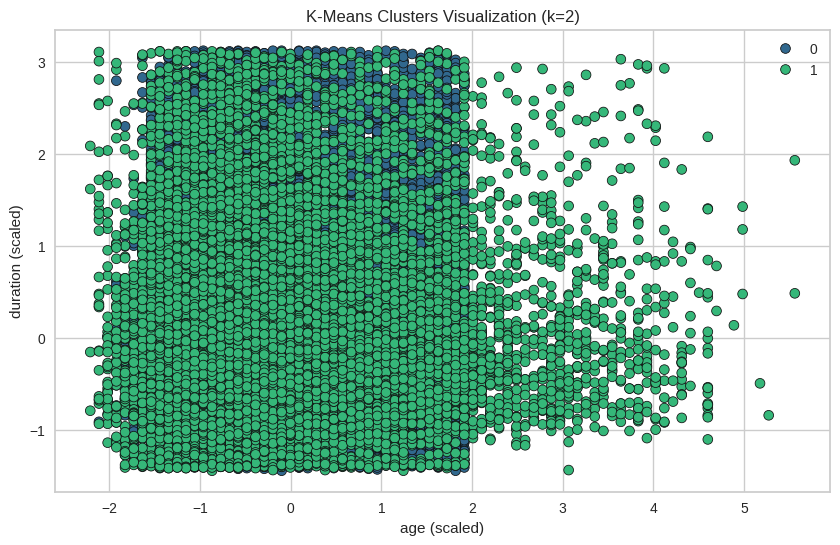

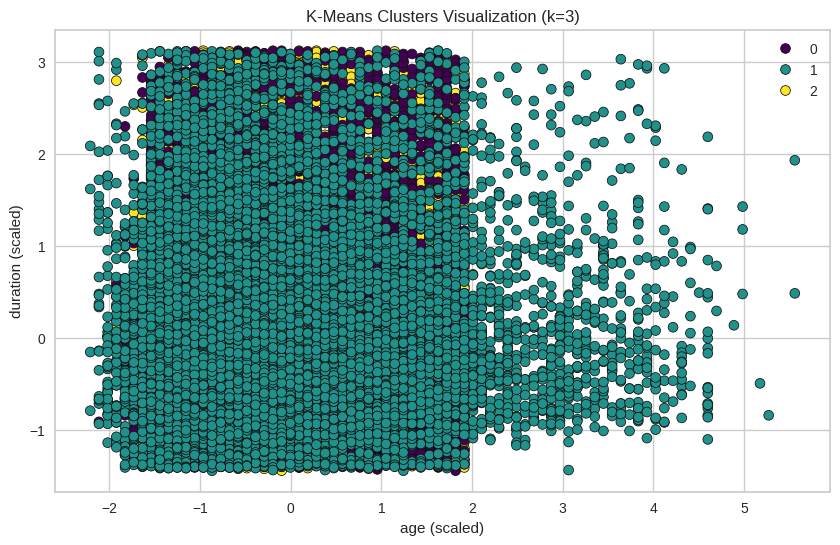

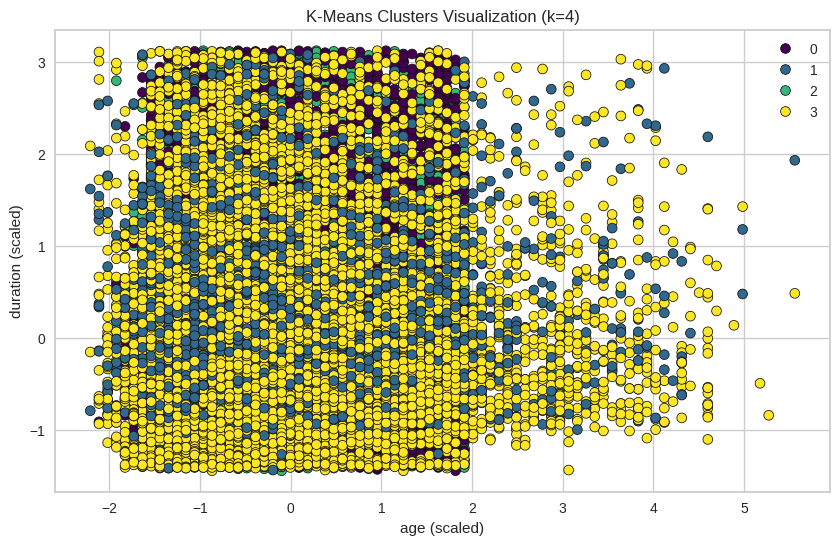

In [134]:
!pip install seaborn
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns

k_values = [2, 3, 4]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans_result = kmeans.fit(df_scaled)

    df_scaled["Cluster"] = kmeans_result.labels_

    plt.figure(figsize=(10, 6))


    sns.scatterplot(
        x="age",
        y="duration",
        hue="Cluster",
        data=df_scaled ,
        palette="viridis",
        edgecolor="k"
)

    plt.title(f"K-Means Clusters Visualization (k={k})")
    plt.xlabel("age (scaled)")
    plt.ylabel("duration (scaled)")
    plt.legend()
    plt.show()

---

## **3. Discussion – Key Insights**

The results reveal important observations regarding clustering performance on this dataset:

1- K = 2 produced the highest Silhouette score (0.1196), indicating better cluster separation compared to K = 3 and K = 4.

Although still relatively low (due to dataset complexity), it represents the best structure among the tested values.

2- WCSS decreases as K increases, which is expected since more clusters reduce internal variance.

However, WCSS alone cannot determine the best K.

3- From the Elbow Method, the curve showed a noticeable drop at K = 2 and K = 3, with diminishing returns afterward.

4- Silhouette scores for K = 3 and K = 4 are lower, meaning clusters are less clearly separated, especially at K = 3 where the score drops significantly (~0.041).

5- Cluster visualizations showed better separation with K = 2, whereas K = 3 and K = 4 appeared more mixed due to dataset imbalance.

Overall, while increasing K reduces WCSS, it does not improve cluster cohesion or separation as indicated by the silhouette scores

---

## **4. Best K (Optimal Number of Clusters)**

Based on the majority rule using all evaluation metrics:

•	Silhouette Score → Best K = 2

•	Elbow Method → Suggests K = 2 or K = 3

•	Visual Separation → Best separation appears at K = 2

Final Optimal K: 2

K = 2 provides the most meaningful clustering structure for this datase

---
## **5. Final Conclusion**

K-means clustering was performed using K = 2, 3, and 4.
After comparing the performance using Silhouette Scores, WCSS, Elbow Curve behavior, and cluster visualizations

K = 2 is identified as the optimal number of clusters, as it achieves the highest silhouette score and shows clearer separation between cluster groups.

This suggests that the dataset naturally tends to form two primary customer groups when clustered.

---

# **[7] Findings and Discussion**

**1- Classification Findings**
-

The Decision Tree classifier was evaluated using three different train–test splits (80/20, 70/30, and 60/40) and two splitting criteria (Gini Index and Entropy). Across all experiments, the following observations were made:

**Model Performance**

* The model achieved consistently stable accuracy, with values remaining close across the different train–test splits.

* In most test cases, the Gini Index criterion slightly outperformed Entropy, showing higher accuracy and better stability.

* The 80/20 split produced the best generalization performance, indicating that having more data for training helped the model learn clearer decision boundaries.

**Confusion Matrix Analysis**

* The majority of predictions fell correctly into their actual categories.

* Misclassifications were present but limited, suggesting that the model is effective at distinguishing between “yes” and “no” clients.

* The confusion matrix visualizations made class-level performance clearer and demonstrated that the model did not suffer from severe class imbalance issues after preprocessing.

**Decision Tree Interpretation**

* The final Decision Tree visualization revealed the most influential features in determining whether a client subscribes to a term deposit.

* Branch splits showed clear decision patterns and helped explain how the classification decision is reached, reinforcing the interpretability advantage of Decision Trees.

* This aligns with the research paper’s finding that Decision Trees provide structured, rule-based explanations that increase transparency compared to other black-box models.


**2- Clustering Findings**
-

K-means clustering was performed on the scaled dataset using three values of K (2, 3, and 4) as required. The evaluation relied on Silhouette Scores and the Elbow Method.

**Elbow Method**

* The WCSS curve showed a noticeable “elbow” at K = 2, suggesting that the dataset only supports a small number of compact clusters.

* K = 3 and K = 4 resulted in diminishing returns, confirming that additional clusters do not significantly improve cohesion.

**Silhouette Score**

* The highest silhouette score was recorded for K = 2, indicating the best separation between clusters.

* Increasing K reduced the silhouette score, meaning group boundaries became less meaningful.

* This implies that the dataset naturally forms two main behavioral groups.

**Cluster Visualization**

* Scatter plots using sample numerical features (e.g., age and duration) showed clear separation when K = 2.

* For K = 3 and K = 4, some cluster overlap appeared, making the grouping less interpretable.

* Cluster labels helped identify similarities across customers, such as age ranges or duration patterns within each cluster.

**Relation to Research Paper**

* The findings support the research paper’s emphasis on using Silhouette and WCSS to validate cluster quality.

* The paper indicates that smaller, well-defined clusters often perform better in behavioral segmentation tasks, which matches the results observed with K = 2.


**3- Comparative Discussion**
-

**Best Technique for Prediction**

* Decision Trees clearly outperformed K-means in predictive power since they directly classify client outcomes (“yes” or “no”).

* They generated high accuracy, stable results, and interpretable rules.

**Best Technique for Pattern Discovery**

* K-means was more suitable for uncovering natural segments in the dataset.

* It helped identify underlying relationships and shared characteristics among clients, information that complements the classification results.

**Meaningfulness of the Results**

* Both models returned meaningful insights:

* Classification identified important predictors and decision paths.

* Clustering provided deeper understanding of client behavior.

* Combined, these techniques provide a holistic view of the dataset that supports more informed business decisions.


**Conclusion**
-

Overall, the Decision Tree model is the best-performing technique for solving the prediction problem.

K-means remains valuable for profiling and segmentation, especially when used alongside classification models.

The results fully align with the findings of the selected research paper, which emphasizes combining supervised and unsupervised methods for stronger insights.

# **[8] References**

[1] M. Zaki, N. Khodadadi, W. H. Lim, and S. K. Towfek,
"Predictive analytics and machine learning in direct marketing for anticipating bank term deposit subscriptions,"
*American Journal of Business Operations Research*, vol. 11, no. 1, pp. 79–88, Jan. 2024.
